# Defender PPO CNN v1

Proximal Policy Optimization (PPO) implementation for Atari Defender, adapted from our Pong PPO implementation.

## Key Adaptations from Pong PPO

### Environment Differences

- **Action space**: Defender has 18 actions (large discrete action space with movement + fire combinations)
- **Reward structure**: Points for destroying enemies and rescuing humanoids. Much higher raw scores than Pong. Rewards are clipped to [-1, 1] for stable training
- **Episode termination**: Losing all lives ends the episode
- **Target reward**: 15000 mean reward over 100 episodes

### Architecture

- **CNN filters**: 32-64-64 (matching the Defender A2C/DQN architecture)
- **Reward clipping**: Clips rewards to [-1, 1] for training stability (tracks raw rewards for evaluation)
- **Larger action space**: 18 actions vs 6 for Pong, requires more exploration

### PPO Recap

PPO collects large batches of experience, then performs multiple epochs of updates with a clipped surrogate objective:

```
ratio = pi_new(a|s) / pi_old(a|s)
L = -min(ratio * A, clip(ratio, 1-eps, 1+eps) * A)
```

This prevents destructively large policy updates while reusing data efficiently.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output
from collections import deque
import cv2
import mlflow
import mlflow.pytorch
import wandb
import os
from dotenv import load_dotenv
from pathlib import Path

# Import logging utilities
from logging_utils import (
    log_hyperparameters,
    log_model_info,
    log_episode_metrics,
    log_a2c_losses,
    save_checkpoint,
    save_training_plot,
    display_training_plot,
    log_final_results,
    setup_weight_tracking,
    log_layer_wise_gradient_norms,
    log_weight_stats
)

import ale_py
gym.register_envs(ale_py)

## Reproducibility

In [2]:
SEED = 24127

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Random seed set to: {SEED}")

Random seed set to: 24127


## Preprocessing Functions

In [3]:
def preprocess_frame(frame):
    """Convert frame to grayscale, crop, resize to 84x84, and normalize."""
    gray = np.mean(frame, axis=2).astype(np.uint8)
    cropped = gray[10:190, :]   # Defender-specific: preserves radar strip; [34:194] crops it out
    resized = cv2.resize(cropped, (84, 84), interpolation=cv2.INTER_AREA)
    return resized.astype(np.float32) / 255.0


class FrameStackEnv(gym.Wrapper):
    """Stack multiple consecutive frames as part of the environment observation.
    Replaces the external FrameStack class — each env in a vectorized setup
    maintains its own frame deque internally."""
    def __init__(self, env, num_frames=4):
        super().__init__(env)
        self.num_frames = num_frames
        self._frames = deque(maxlen=num_frames)
        low = np.zeros((num_frames, 84, 84), dtype=np.float32)
        high = np.ones((num_frames, 84, 84), dtype=np.float32)
        self.observation_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        processed = preprocess_frame(obs)
        for _ in range(self.num_frames):
            self._frames.append(processed)
        return np.stack(list(self._frames), axis=0), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self._frames.append(preprocess_frame(obs))
        return np.stack(list(self._frames), axis=0), reward, terminated, truncated, info


class NoopResetEnv(gym.Wrapper):
    """Take a random number of noop actions on reset for stochastic starts."""
    def __init__(self, env, noop_max=30):
        super().__init__(env)
        self.noop_max = noop_max

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        noops = np.random.randint(1, self.noop_max + 1)
        for _ in range(noops):
            obs, _, terminated, truncated, info = self.env.step(0)
            if terminated or truncated:
                obs, info = self.env.reset(**kwargs)
        return obs, info


class FireResetEnv(gym.Wrapper):
    """Press FIRE on reset — required to unfreeze Defender after a life loss or game start."""
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        obs, _, terminated, truncated, _ = self.env.step(1)  # action 1 = FIRE
        if terminated or truncated:
            obs, info = self.env.reset(**kwargs)
        return obs, info


class MaxAndSkipEnv(gym.Wrapper):
    """Return only every skip-th frame, max-pooling over the last 2 to handle sprite flicker."""
    def __init__(self, env, skip=4):
        super().__init__(env)
        self._skip = skip
        self._obs_buffer = np.zeros((2, *env.observation_space.shape), dtype=np.uint8)

    def step(self, action):
        total_reward = 0.0
        terminated = False
        truncated = False
        for i in range(self._skip):
            obs, reward, terminated, truncated, info = self.env.step(action)
            if i == self._skip - 2:
                self._obs_buffer[0] = obs
            if i == self._skip - 1:
                self._obs_buffer[1] = obs
            total_reward += reward
            if terminated or truncated:
                break
        max_frame = self._obs_buffer.max(axis=0)
        return max_frame, total_reward, terminated, truncated, info

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._obs_buffer[:] = 0
        self._obs_buffer[1] = obs
        return obs, info


class EpisodicLifeEnv(gym.Wrapper):
    """Treat each life loss as episode end; only truly reset on game over.
    Exposes 'real_done' in info for tracking full-game rewards."""
    def __init__(self, env):
        super().__init__(env)
        self.lives = 0
        self.was_real_done = True
        self._last_obs = None

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self._last_obs = obs
        self.was_real_done = terminated or truncated
        lives = self.env.unwrapped.ale.lives()
        if lives < self.lives and lives > 0:
            terminated = True   # fake done on life loss
        self.lives = lives
        info['real_done'] = self.was_real_done
        return obs, reward, terminated, truncated, info

    def reset(self, **kwargs):
        if self.was_real_done:
            obs, info = self.env.reset(**kwargs)
        else:
            obs = self._last_obs   # continue same game after life-loss reset
            info = {}
        self.lives = self.env.unwrapped.ale.lives()
        return obs, info


def make_env(seed=None, frame_skip=4, noop_max=30):
    """Create Defender with standard Atari preprocessing wrappers."""
    env = gym.make('DefenderNoFrameskip-v4')
    if seed is not None:
        env.reset(seed=seed)
    env = NoopResetEnv(env, noop_max=noop_max)
    env = FireResetEnv(env)
    env = MaxAndSkipEnv(env, skip=frame_skip)
    env = EpisodicLifeEnv(env)
    env = FrameStackEnv(env, num_frames=4)
    return env


def make_env_fn(seed=None, frame_skip=4, noop_max=30):
    """Factory function for vectorized env creation."""
    def _init():
        return make_env(seed=seed, frame_skip=frame_skip, noop_max=noop_max)
    return _init

## PPO Network

Shared CNN features with separate actor and critic heads. Uses 32-64-64 filters (matching the Defender A2C/DQN architecture).

In [4]:
class PPOAgent(nn.Module):
    """PPO Agent with shared CNN features, actor head, and critic head."""
    
    def __init__(self, input_channels, action_size):
        super(PPOAgent, self).__init__()
        
        # Shared CNN feature extractor (32->64->64 filters, standard Atari architecture)
        self.conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )
        
        # Calculate feature size
        self.feature_size = self._get_conv_output_size(input_channels)
        
        # Actor head (policy)
        self.actor_fc = nn.Linear(self.feature_size, 512)
        self.policy_head = nn.Linear(512, action_size)
        
        # Critic head (value)
        self.critic_fc = nn.Linear(self.feature_size, 512)
        self.value_head = nn.Linear(512, 1)
        
        self.action_size = action_size
        
        # Orthogonal weight initialization — critical for PPO stability
        self._init_weights()
    
    def _init_weights(self):
        """Orthogonal init with gain=sqrt(2) for CNN/FC, small gain for output heads."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.constant_(m.bias, 0)
        # Policy head: tiny gain → near-uniform initial distribution over 18 actions
        nn.init.orthogonal_(self.policy_head.weight, gain=0.01)
        nn.init.constant_(self.policy_head.bias, 0)
        # Value head: unit gain
        nn.init.orthogonal_(self.value_head.weight, gain=1.0)
        nn.init.constant_(self.value_head.bias, 0)
    
    def _get_conv_output_size(self, input_channels):
        """Calculate the output size of conv layers."""
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, 84, 84)
            conv_output = self.conv(dummy_input)
            return conv_output.numel() // conv_output.size(0)
    
    def forward(self, state):
        """Forward pass: returns policy logits and value estimate."""
        # Shared CNN features
        features = self.conv(state)
        features = features.view(features.size(0), -1)
        
        # Actor: policy logits
        actor_hidden = F.relu(self.actor_fc(features))
        logits = self.policy_head(actor_hidden)
        
        # Critic: value estimate
        critic_hidden = F.relu(self.critic_fc(features))
        value = self.value_head(critic_hidden).squeeze(-1)
        
        return logits, value
    
    def get_action(self, state):
        """Sample action from policy and return action, log_prob, value."""
        logits, value = self.forward(state)
        probs = F.softmax(logits, dim=-1)
        
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        
        return action, log_prob, value
    
    def evaluate_actions(self, states, actions):
        """Evaluate actions for PPO update: returns log_probs, values, entropy."""
        logits, values = self.forward(states)
        probs = F.softmax(logits, dim=-1)
        
        dist = torch.distributions.Categorical(probs)
        log_probs = dist.log_prob(actions)
        entropy = dist.entropy()
        
        return log_probs, values, entropy

## Rollout Buffer

Stores experience for PPO training. Unlike A2C which updates after a few steps, PPO collects a large batch before updating.

In [5]:
class RolloutBuffer:
    """Buffer to store rollout experience for PPO, supporting N parallel envs.

    add() accepts per-step arrays of shape (n_envs, ...).
    compute_gae() flattens everything to (rollout_length * n_envs,) for batching.
    """

    def __init__(self, n_envs=1):
        self.n_envs = n_envs
        self.states = []
        self.actions = []
        self.rewards = []
        self.dones = []
        self.values = []
        self.log_probs = []

        # Computed after rollout (flat arrays)
        self.advantages = None
        self.returns = None
        self._flat_states = None
        self._flat_actions = None
        self._flat_log_probs = None
        self._flat_values = None

    def add(self, states, actions, rewards, dones, values, log_probs):
        """Add one timestep of transitions for all n_envs."""
        self.states.append(states.copy())      # (n_envs, C, H, W)
        self.actions.append(actions.copy())    # (n_envs,)
        self.rewards.append(rewards.copy())    # (n_envs,)
        self.dones.append(dones.copy())        # (n_envs,)
        self.values.append(values.copy())      # (n_envs,)
        self.log_probs.append(log_probs.copy()) # (n_envs,)

    def compute_gae(self, last_values, gamma, gae_lambda):
        """Compute GAE for N parallel envs, then flatten to (T * N,).

        last_values: array of shape (n_envs,) — value estimates for the state
                     after the final rollout step.
        """
        T = len(self.rewards)
        N = self.n_envs

        rewards = np.array(self.rewards)     # (T, N)
        dones   = np.array(self.dones)       # (T, N)
        values  = np.array(self.values)      # (T, N)
        last_vals = np.asarray(last_values)  # (N,)

        advantages = np.zeros((T, N), dtype=np.float32)
        gae = np.zeros(N, dtype=np.float32)

        for t in reversed(range(T)):
            next_val = values[t + 1] if t < T - 1 else last_vals
            delta = rewards[t] + gamma * next_val * (1 - dones[t]) - values[t]
            gae = delta + gamma * gae_lambda * (1 - dones[t]) * gae
            advantages[t] = gae

        returns = advantages + values  # (T, N)

        # Flatten (T, N) -> (T*N,) in row-major order for minibatch sampling
        self.advantages = advantages.reshape(-1)
        self.returns = returns.reshape(-1)

        states_arr = np.array(self.states)                         # (T, N, C, H, W)
        self._flat_states = states_arr.reshape(T * N, *states_arr.shape[2:])
        self._flat_actions = np.array(self.actions).reshape(-1)
        self._flat_log_probs = np.array(self.log_probs).reshape(-1)
        self._flat_values = np.array(self.values).reshape(-1)

    def get_batches(self, batch_size, device):
        """Generate minibatches for training. Yields 6 tensors including old_values."""
        n_samples = len(self._flat_states)
        indices = np.random.permutation(n_samples)

        states       = torch.FloatTensor(self._flat_states).to(device)
        actions      = torch.LongTensor(self._flat_actions).to(device)
        old_log_probs = torch.FloatTensor(self._flat_log_probs).to(device)
        advantages   = torch.FloatTensor(self.advantages).to(device)
        returns      = torch.FloatTensor(self.returns).to(device)
        old_values   = torch.FloatTensor(self._flat_values).to(device)

        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        for start in range(0, n_samples, batch_size):
            end = start + batch_size
            batch_indices = indices[start:end]

            yield (
                states[batch_indices],
                actions[batch_indices],
                old_log_probs[batch_indices],
                advantages[batch_indices],
                returns[batch_indices],
                old_values[batch_indices],
            )

    def clear(self):
        """Clear the buffer."""
        self.states = []
        self.actions = []
        self.rewards = []
        self.dones = []
        self.values = []
        self.log_probs = []
        self.advantages = None
        self.returns = None
        self._flat_states = None
        self._flat_actions = None
        self._flat_log_probs = None
        self._flat_values = None

    def __len__(self):
        return len(self.states) * self.n_envs

## PPO Loss Functions

In [6]:
def compute_ppo_loss(agent, states, actions, old_log_probs, advantages, returns,
                     old_values, clip_epsilon, value_loss_coef, entropy_coef):
    """
    Compute PPO loss with clipped surrogate objective and unclipped value loss.

    Value clipping is omitted: applying clip_epsilon=0.2 to raw value estimates is
    dimensionally wrong — values can range up to ~100 (1/(1-gamma) with reward clipping)
    so a ±0.2 clip severely throttles critic convergence, producing biased advantages
    and slowing the actor in turn.

    Returns:
        total_loss: Combined loss for backprop
        policy_loss: Clipped surrogate loss
        value_loss: Unclipped MSE loss for value function
        entropy_loss: Negative entropy (for loss minimization)
        ratio: Probability ratios (for clip-fraction monitoring)
        approx_kl: Approximate KL divergence (for early-stop monitoring)
    """
    # Get current policy evaluation
    new_log_probs, values, entropy = agent.evaluate_actions(states, actions)

    # Policy loss with clipping
    log_ratio = new_log_probs - old_log_probs
    ratio = torch.exp(log_ratio)

    surr1 = ratio * advantages
    surr2 = torch.clamp(ratio, 1.0 - clip_epsilon, 1.0 + clip_epsilon) * advantages
    policy_loss = -torch.min(surr1, surr2).mean()

    # Value loss — unclipped MSE
    value_loss = 0.5 * ((values - returns) ** 2).mean()

    # Entropy loss (negative because we want to maximize entropy)
    entropy_loss = -entropy.mean()

    # Total loss
    total_loss = policy_loss + value_loss_coef * value_loss + entropy_coef * entropy_loss

    # Approximate KL divergence: E[(ratio - 1) - log(ratio)]  (unbiased estimator)
    with torch.no_grad():
        approx_kl = ((ratio - 1) - log_ratio).mean().item()

    return total_loss, policy_loss, value_loss, entropy_loss, ratio, approx_kl

## Hyperparameters and Setup

In [ ]:
# PPO Hyperparameters
LEARNING_RATE = 2.5e-4
GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_EPSILON = 0.2
VALUE_LOSS_COEF = 0.5
ENTROPY_COEF = 0.05          # Increased from 0.02 — prevents entropy collapse in 18-action space
TARGET_KL = 0.03             # Raised from 0.01 — tight threshold causes excessive early stopping with 18-action entropy
MAX_GRAD_NORM = 0.5

# PPO-specific parameters
N_ENVS = 8                   # Parallel environments for diverse, decorrelated experience
ROLLOUT_LENGTH = 1024        # Steps per rollout per env (total batch = N_ENVS * ROLLOUT_LENGTH)
PPO_EPOCHS = 4               # Number of epochs per update
MINIBATCH_SIZE = 256         # Minibatch size (scaled up from 32 to match 8x larger batch)

# Training parameters
MEAN_REWARD_BOUND = 15000    # Defender target (full-game score)

# Environment parameters
FRAME_SKIP = 4               # Handled inside MaxAndSkipEnv
INPUT_CHANNELS = 4           # Stack 4 frames for velocity information

# Logging
LOG_FREQ = 100
CHECKPOINT_FREQ = 500
GRADIENT_LOG_FREQ = 100

# Architecture
ARCHITECTURE_NAME = "CNN-PPO-Defender"
MODEL_FILTERS = "32-64-64"

# Hyperparameters dict
HYPERPARAMETERS = {
    "algorithm": "PPO",
    "game": "Defender",
    "seed": SEED,
    "learning_rate": LEARNING_RATE,
    "gamma": GAMMA,
    "gae_lambda": GAE_LAMBDA,
    "clip_epsilon": CLIP_EPSILON,
    "value_loss_coef": VALUE_LOSS_COEF,
    "entropy_coef": ENTROPY_COEF,
    "target_kl": TARGET_KL,
    "max_grad_norm": MAX_GRAD_NORM,
    "n_envs": N_ENVS,
    "rollout_length": ROLLOUT_LENGTH,
    "ppo_epochs": PPO_EPOCHS,
    "minibatch_size": MINIBATCH_SIZE,
    "mean_reward_bound": MEAN_REWARD_BOUND,
    "frame_skip": FRAME_SKIP,
    "input_channels": INPUT_CHANNELS,
    "architecture": ARCHITECTURE_NAME,
    "model_filters": MODEL_FILTERS,
    "reward_clipping": True,
    "frame_crop": "10:190",
    "value_loss_clipping": False,
    "wrappers": "NoopResetEnv+FireResetEnv+MaxAndSkipEnv+EpisodicLifeEnv+FrameStackEnv",
}

# Setup directories
RL_STUDY_DIR = Path.cwd().parent.parent if Path.cwd().name == 'defender_ppo_cnn' else Path.cwd()
MLFLOW_TRACKING_URI = RL_STUDY_DIR / 'mlruns'
WANDB_DIR = RL_STUDY_DIR / 'wandb'
BASE_ARTIFACTS_DIR = RL_STUDY_DIR / 'artifacts'

# Create directories
WANDB_DIR.mkdir(exist_ok=True)
BASE_ARTIFACTS_DIR.mkdir(exist_ok=True)
MLFLOW_TRACKING_URI.mkdir(exist_ok=True)

# Configure MLflow
mlflow.set_tracking_uri(f'file://{MLFLOW_TRACKING_URI}')

# Configure wandb — finish any active run before starting a fresh one
if wandb.run is not None:
    wandb.finish()

os.environ['WANDB_DIR'] = str(WANDB_DIR)
load_dotenv(RL_STUDY_DIR / '.env')
wandb_key = os.getenv('WANDB_KEY')
wandb.login(key=wandb_key)

wandb.init(
    project="defender_ppo_training",
    name="defender_cnn_ppo_v1",
    dir=str(WANDB_DIR),
    config=HYPERPARAMETERS,
    resume="never",   # always create a fresh run — avoids step-monotonicity conflicts
)

print(f"Setup complete! WandB run: {wandb.run.name} ({wandb.run.id})")
print(f"Random seed: {SEED}")
print(f"Parallel envs: {N_ENVS} | Rollout: {ROLLOUT_LENGTH} steps/env | Total batch: {N_ENVS * ROLLOUT_LENGTH:,}")
print(f"PPO epochs: {PPO_EPOCHS} | Minibatch: {MINIBATCH_SIZE}")
print(f"Clip epsilon: {CLIP_EPSILON}, GAE lambda: {GAE_LAMBDA}, LR: {LEARNING_RATE}")
print(f"Entropy coef: {ENTROPY_COEF} | Target KL: {TARGET_KL} | Training runs until target {MEAN_REWARD_BOUND} is reached")
print(f"Wrappers: NoopResetEnv + FireResetEnv + MaxAndSkipEnv(skip={FRAME_SKIP}) + EpisodicLifeEnv + FrameStackEnv")
print(f"Frame crop: [10:190] (includes radar) | Value loss clipping: disabled")
print(f"Frame stack: {INPUT_CHANNELS} frames")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/bmartins/.netrc
wandb: Currently logged in as: bmartins to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Setup complete! WandB run: defender_cnn_ppo_v1 (ogfb5vb6)
Random seed: 24127
Parallel envs: 8 | Rollout: 1024 steps/env | Total batch: 8,192
PPO epochs: 4 | Minibatch: 256
Clip epsilon: 0.2, GAE lambda: 0.95, LR: 0.00025
Entropy coef: 0.05 | Target KL: 0.03 | Training runs until target 15000 is reached
Wrappers: NoopResetEnv + FireResetEnv + MaxAndSkipEnv(skip=4) + EpisodicLifeEnv + FrameStackEnv
Frame crop: [10:190] (includes radar) | Value loss clipping: disabled
Frame stack: 4 frames


wandb: WARNING Tried to log to step 195954 that is less than the current step 195955. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 203808 that is less than the current step 203809. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 225121 that is less than the current step 225122. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 254396 that is less than the current step 254397. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 284453 that is less than the current step 284454. Steps must be monotonically increasing, so thi

## PPO Training Function

In [ ]:
def train_ppo():
    # End any active runs
    if mlflow.active_run():
        mlflow.end_run()

    # MLflow experiment setup
    mlflow.set_experiment("defender_ppo_training")

    with mlflow.start_run():
        # Create artifacts directory
        run_id = mlflow.active_run().info.run_id
        artifacts_dir = BASE_ARTIFACTS_DIR / f"run_{run_id}"
        artifacts_dir.mkdir(parents=True, exist_ok=True)
        print(f"Artifacts will be saved to: {artifacts_dir}")

        # Log hyperparameters
        log_hyperparameters(HYPERPARAMETERS)

        # Environment setup: N_ENVS parallel environments.
        # Each env runs independently with its own FrameStackEnv, EpisodicLifeEnv, etc.
        # Use SyncVectorEnv if AsyncVectorEnv causes issues in your environment.
        envs = gym.vector.AsyncVectorEnv([
            make_env_fn(seed=SEED + i, frame_skip=FRAME_SKIP)
            for i in range(N_ENVS)
        ])
        action_size = envs.single_action_space.n

        # Device
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {device}")

        # Create agent (weights initialised orthogonally inside __init__)
        agent = PPOAgent(input_channels=INPUT_CHANNELS, action_size=action_size).to(device)
        optimizer = optim.Adam(agent.parameters(), lr=LEARNING_RATE, eps=1e-5)

        # Setup weight tracking
        setup_weight_tracking(agent, log_freq=GRADIENT_LOG_FREQ, log_all=True)

        # Log model info
        total_params = log_model_info(agent)
        print(f"Total parameters: {total_params:,}")

        # Training state
        rollout_buffer = RolloutBuffer(n_envs=N_ENVS)
        episode_rewards = []      # Per-life rewards (training signal)
        game_rewards = []         # Full-game rewards (stopping criterion)
        episode = 0
        total_timesteps = 0
        total_updates = 0

        # Per-env tracking
        current_ep_rewards  = np.zeros(N_ENVS)
        current_ep_lengths  = np.zeros(N_ENVS, dtype=int)
        current_game_rewards = np.zeros(N_ENVS)

        # Initial reset: obs_array is (N_ENVS, 4, 84, 84) from FrameStackEnv
        obs_array, _ = envs.reset()

        print(f"Starting PPO training on Defender with {N_ENVS} parallel envs...\n")

        while True:
            # ── Collect rollout ────────────────────────────────────────────────
            rollout_buffer.clear()

            for _ in range(ROLLOUT_LENGTH):
                state_tensor = torch.FloatTensor(obs_array).to(device)  # (N_ENVS, 4, 84, 84)

                with torch.no_grad():
                    actions, log_probs, values = agent.get_action(state_tensor)

                actions_np = actions.cpu().numpy()
                next_obs_array, step_rewards, terminated, truncated, infos = envs.step(actions_np)
                dones = (terminated | truncated).astype(float)

                # Clip rewards for training stability
                step_rewards_clipped = np.clip(step_rewards, -1.0, 1.0)

                rollout_buffer.add(
                    states=obs_array,
                    actions=actions_np,
                    rewards=step_rewards_clipped,
                    dones=dones,
                    values=values.cpu().numpy(),
                    log_probs=log_probs.cpu().numpy()
                )

                current_ep_rewards  += step_rewards
                current_ep_lengths  += 1
                current_game_rewards += step_rewards
                total_timesteps += N_ENVS

                # Handle completed episodes per env
                for i in range(N_ENVS):
                    if dones[i]:
                        episode_rewards.append(current_ep_rewards[i])
                        mean_life_reward = (np.mean(episode_rewards[-100:]) if len(episode_rewards) >= 100
                                            else np.mean(episode_rewards))

                        log_episode_metrics(current_ep_rewards[i], mean_life_reward,
                                            current_ep_lengths[i], episode, total_updates)

                        if episode % 10 == 0:
                            avg_life = (np.mean(episode_rewards[-10:]) if len(episode_rewards) >= 10
                                        else np.mean(episode_rewards))
                            print(f"Episode {episode:4d} | Life Reward: {current_ep_rewards[i]:8.1f} | "
                                  f"Avg(10): {avg_life:8.2f} | Steps: {total_timesteps:,}")

                        current_ep_rewards[i] = 0
                        current_ep_lengths[i] = 0
                        episode += 1

                        # Check real_done for full-game tracking.
                        # gymnasium AsyncVectorEnv stores terminal info in infos["final_info"].
                        real_done = False
                        if "final_info" in infos and infos["final_info"] is not None:
                            fi = infos["final_info"]
                            if i < len(fi) and fi[i] is not None:
                                real_done = fi[i].get("real_done", False)

                        if real_done:
                            game_rewards.append(current_game_rewards[i])
                            current_game_rewards[i] = 0

                            mean_game_reward = (np.mean(game_rewards[-100:]) if len(game_rewards) >= 100
                                                else np.mean(game_rewards))
                            if episode % 10 == 0:
                                print(f"  -> Game {len(game_rewards):3d} | Score: {game_rewards[-1]:8.1f} | "
                                      f"Mean(100): {mean_game_reward:8.2f}")

                            if mean_game_reward >= MEAN_REWARD_BOUND:
                                print(f"\nEnvironment solved in {len(game_rewards)} games!")
                                print(f"Mean game reward: {mean_game_reward:.2f} >= {MEAN_REWARD_BOUND}")
                                wandb.log({"solved_at_game": len(game_rewards)}, step=total_updates)
                                log_final_results(agent, episode, mean_game_reward,
                                                  game_rewards, artifacts_dir, run_id)
                                envs.close()
                                wandb.finish()
                                return agent, game_rewards

                obs_array = next_obs_array

            # ── Compute GAE ────────────────────────────────────────────────────
            with torch.no_grad():
                last_state_tensor = torch.FloatTensor(obs_array).to(device)
                _, last_values = agent.forward(last_state_tensor)
                last_values = last_values.cpu().numpy()  # (N_ENVS,)

            rollout_buffer.compute_gae(last_values, GAMMA, GAE_LAMBDA)

            # ── PPO update ─────────────────────────────────────────────────────
            epoch_policy_losses  = []
            epoch_value_losses   = []
            epoch_entropy_losses = []
            epoch_total_losses   = []
            epoch_clip_fractions = []
            epoch_approx_kls     = []
            epochs_completed     = 0
            kl_triggered         = False

            for epoch in range(PPO_EPOCHS):
                for batch in rollout_buffer.get_batches(MINIBATCH_SIZE, device):
                    states, actions, old_log_probs, advantages, returns, old_values = batch

                    total_loss, policy_loss, value_loss, entropy_loss, ratio, approx_kl = compute_ppo_loss(
                        agent, states, actions, old_log_probs, advantages, returns,
                        old_values, CLIP_EPSILON, VALUE_LOSS_COEF, ENTROPY_COEF
                    )

                    optimizer.zero_grad()
                    total_loss.backward()
                    torch.nn.utils.clip_grad_norm_(agent.parameters(), MAX_GRAD_NORM)
                    optimizer.step()

                    epoch_policy_losses.append(policy_loss.item())
                    epoch_value_losses.append(value_loss.item())
                    epoch_entropy_losses.append(entropy_loss.item())
                    epoch_total_losses.append(total_loss.item())
                    epoch_approx_kls.append(approx_kl)

                    clip_fraction = torch.mean((torch.abs(ratio - 1.0) > CLIP_EPSILON).float()).item()
                    epoch_clip_fractions.append(clip_fraction)

                    total_updates += 1

                    if approx_kl > TARGET_KL:
                        kl_triggered = True
                        break

                epochs_completed += 1
                if kl_triggered:
                    break

            # ── Log losses ─────────────────────────────────────────────────────
            avg_policy_loss   = np.mean(epoch_policy_losses)
            avg_value_loss    = np.mean(epoch_value_losses)
            avg_entropy_loss  = np.mean(epoch_entropy_losses)
            avg_total_loss    = np.mean(epoch_total_losses)
            avg_clip_fraction = np.mean(epoch_clip_fractions)
            avg_approx_kl     = np.mean(epoch_approx_kls)

            log_a2c_losses(avg_policy_loss, avg_value_loss, avg_entropy_loss,
                           avg_total_loss, episode, total_updates)

            wandb.log({
                "ppo/clip_fraction": avg_clip_fraction,
                "ppo/approx_kl": avg_approx_kl,
                "ppo/epochs_completed": epochs_completed,
                "ppo/kl_triggered": float(kl_triggered),
                "system/total_timesteps": total_timesteps,
            }, step=total_updates)

            if total_updates % GRADIENT_LOG_FREQ == 0:
                log_layer_wise_gradient_norms(agent, total_updates)

            if episode % 100 == 0 and episode > 0 and len(episode_rewards) > 0:
                display_training_plot(episode_rewards, MEAN_REWARD_BOUND)

            if episode % CHECKPOINT_FREQ == 0 and episode > 0:
                save_checkpoint(artifacts_dir, episode, agent, optimizer,
                                episode_rewards, run_id, total_updates)
                save_training_plot(artifacts_dir, episode_rewards, episode, MEAN_REWARD_BOUND)

## Test Network Architecture

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Input shape: torch.Size([1, 4, 84, 84])
Logits shape: torch.Size([1, 18])
Value: -0.0174
Action: 6
Log prob: -2.8899
Entropy: 2.8904  (max possible: 2.8904)
Action space size (Defender): 18

Total parameters: 3,300,019
Shared CNN: 77,984 (2.4%)
Actor: 1,615,378 (49.0%)
Critic: 1,606,657 (48.7%)

Orthogonal init check:
  Policy head weight std: 0.0004 (should be ~0.01)
  Initial entropy: 2.8904 (should be near 2.8904)


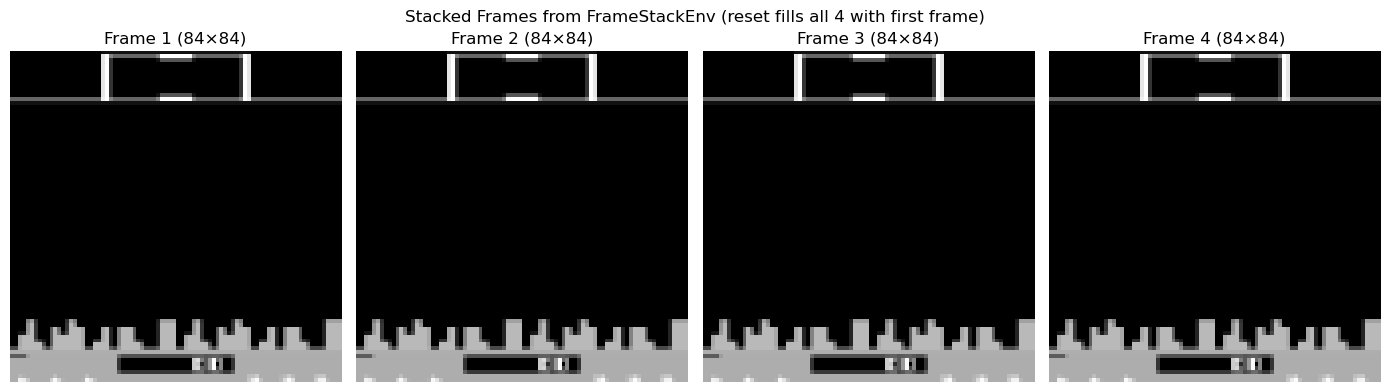

In [9]:
# Test the network architecture (must match training config: 4 frames, wrapped env)
env = make_env()
obs, _ = env.reset()  # obs is (4, 84, 84) directly from FrameStackEnv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_agent = PPOAgent(input_channels=4, action_size=env.action_space.n).to(device)

with torch.no_grad():
    state_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
    logits, value = test_agent(state_tensor)
    action, log_prob, _ = test_agent.get_action(state_tensor)

    # Test evaluate_actions
    new_log_prob, new_value, entropy = test_agent.evaluate_actions(state_tensor, action)

print(f"Input shape: {state_tensor.shape}")
print(f"Logits shape: {logits.shape}")
print(f"Value: {value.item():.4f}")
print(f"Action: {action.item()}")
print(f"Log prob: {log_prob.item():.4f}")
print(f"Entropy: {entropy.item():.4f}  (max possible: {np.log(env.action_space.n):.4f})")
print(f"Action space size (Defender): {env.action_space.n}")

total_params = sum(p.numel() for p in test_agent.parameters())
conv_params = sum(p.numel() for name, p in test_agent.named_parameters() if 'conv' in name)
actor_params = sum(p.numel() for name, p in test_agent.named_parameters() if 'actor' in name or 'policy' in name)
critic_params = sum(p.numel() for name, p in test_agent.named_parameters() if 'critic' in name or 'value' in name)

print(f"\nTotal parameters: {total_params:,}")
print(f"Shared CNN: {conv_params:,} ({conv_params/total_params*100:.1f}%)")
print(f"Actor: {actor_params:,} ({actor_params/total_params*100:.1f}%)")
print(f"Critic: {critic_params:,} ({critic_params/total_params*100:.1f}%)")

# Verify orthogonal init: policy logits should be near-uniform (high entropy)
print(f"\nOrthogonal init check:")
print(f"  Policy head weight std: {test_agent.policy_head.weight.std().item():.4f} (should be ~0.01)")
print(f"  Initial entropy: {entropy.item():.4f} (should be near {np.log(env.action_space.n):.4f})")

# Show the 4 stacked frames (obs is (4, 84, 84) from FrameStackEnv)
plt.figure(figsize=(14, 4))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(obs[i], cmap='gray')
    plt.title(f'Frame {i + 1} (84×84)')
    plt.axis('off')
plt.suptitle('Stacked Frames from FrameStackEnv (reset fills all 4 with first frame)')
plt.tight_layout()
plt.show()

env.close()

## Test Rollout Buffer and GAE

In [10]:
# Test rollout buffer with n_envs=4 (smaller than training for a quick sanity check)
N_TEST_ENVS = 4
test_buffer = RolloutBuffer(n_envs=N_TEST_ENVS)

for i in range(10):
    test_buffer.add(
        states=np.random.randn(N_TEST_ENVS, 4, 84, 84).astype(np.float32),
        actions=np.random.randint(0, 18, size=N_TEST_ENVS),
        rewards=np.random.randn(N_TEST_ENVS).astype(np.float32),
        dones=(np.zeros(N_TEST_ENVS) if i < 9 else np.ones(N_TEST_ENVS)).astype(float),
        values=np.random.randn(N_TEST_ENVS).astype(np.float32),
        log_probs=np.random.randn(N_TEST_ENVS).astype(np.float32)
    )

print(f"Buffer timesteps: {len(test_buffer.states)}, envs: {test_buffer.n_envs}")
print(f"Total samples (timesteps × envs): {len(test_buffer)}")

# Test GAE computation with multi-env last values
last_values = np.zeros(N_TEST_ENVS)
test_buffer.compute_gae(last_values, gamma=0.99, gae_lambda=0.95)

print(f"Advantages shape: {test_buffer.advantages.shape}")    # (10 * 4,) = (40,)
print(f"Returns shape:    {test_buffer.returns.shape}")
print(f"Flat states shape: {test_buffer._flat_states.shape}")  # (40, 4, 84, 84)
print(f"Sample advantages: {test_buffer.advantages[:4]}")

# Test batch generation — should yield 6 tensors including old_values
device = torch.device("cpu")
batch_count = 0
for batch in test_buffer.get_batches(batch_size=16, device=device):
    states, actions, old_log_probs, advantages, returns, old_values = batch
    batch_count += 1
    if batch_count == 1:
        print(f"\nFirst batch shapes:")
        print(f"  States:        {states.shape}")
        print(f"  Actions:       {actions.shape}")
        print(f"  Old log probs: {old_log_probs.shape}")
        print(f"  Advantages:    {advantages.shape}")
        print(f"  Returns:       {returns.shape}")
        print(f"  Old values:    {old_values.shape}")

print(f"\nTotal batches: {batch_count}  (expected: {-(-len(test_buffer) // 16)})")

Buffer timesteps: 10, envs: 4
Total samples (timesteps × envs): 40
Advantages shape: (40,)
Returns shape:    (40,)
Flat states shape: (40, 4, 84, 84)
Sample advantages: [-0.7661171   0.08723827  1.5691845   1.2347599 ]

First batch shapes:
  States:        torch.Size([16, 4, 84, 84])
  Actions:       torch.Size([16])
  Old log probs: torch.Size([16])
  Advantages:    torch.Size([16])
  Returns:       torch.Size([16])
  Old values:    torch.Size([16])

Total batches: 3  (expected: 3)


## Start Training

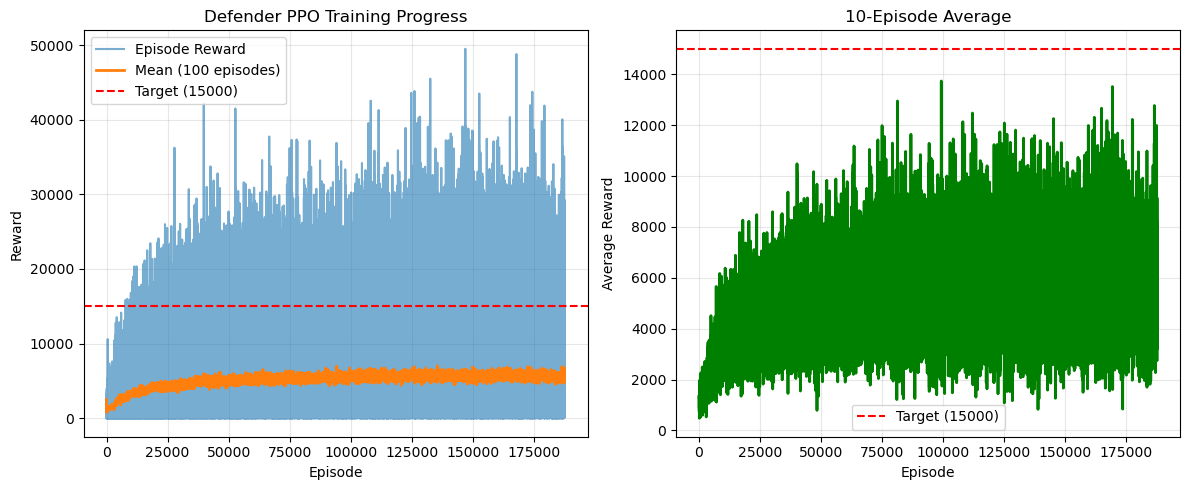

Episode 187600 | Life Reward:   3450.0 | Avg(10):  4005.00 | Steps: 106,258,624
Episode 187610 | Life Reward:   6150.0 | Avg(10):  3140.00 | Steps: 106,264,696
Episode 187620 | Life Reward:  16050.0 | Avg(10):  8960.00 | Steps: 106,269,960
Episode 187630 | Life Reward:   2850.0 | Avg(10):  7215.00 | Steps: 106,276,440
Episode 187640 | Life Reward:   1050.0 | Avg(10):  3785.00 | Steps: 106,279,248
Episode 187650 | Life Reward:   6200.0 | Avg(10):  4570.00 | Steps: 106,286,416
Episode 187660 | Life Reward:    200.0 | Avg(10):  5095.00 | Steps: 106,290,768
Episode 187670 | Life Reward:  10900.0 | Avg(10):  4305.00 | Steps: 106,296,744
Episode 187680 | Life Reward:   8900.0 | Avg(10):  4580.00 | Steps: 106,302,032
Episode 187690 | Life Reward:   4300.0 | Avg(10):  5500.00 | Steps: 106,308,688
Episode 187700 | Life Reward:   6300.0 | Avg(10):  5735.00 | Steps: 106,314,192
Episode 187710 | Life Reward:   6200.0 | Avg(10):  6305.00 | Steps: 106,318,800
Episode 187720 | Life Reward:    150.0 |

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7429ab99d220>>
Traceback (most recent call last):
  File "/home/bmartins/anaconda3/envs/rl_study_312/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


BrokenPipeError: [Errno 32] Broken pipe

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x74282cf768a0>> (for post_run_cell), with arguments args (<ExecutionResult object at 742814550290, execution_count=11 error_before_exec=None error_in_exec=[Errno 32] Broken pipe info=<ExecutionInfo object at 742814553380, raw_cell="# Ensure no active MLflow runs
if mlflow.active_ru.." transformed_cell="# Ensure no active MLflow runs
if mlflow.active_ru.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/home/bmartins/dev/rl_study/src/defender_ppo_cnn/defender_ppo_cnn_v1.ipynb#Y263sZmlsZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [11]:
# Ensure no active MLflow runs
if mlflow.active_run():
    print("Ending active MLflow run...")
    mlflow.end_run()

# Train the agent
trained_agent, rewards = train_ppo()
print("\nTraining completed!")

## Final Results Plot

In [ ]:
# Plot final results
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(rewards, alpha=0.6, label='Episode Reward')
if len(rewards) >= 100:
    moving_avg = [np.mean(rewards[max(0, i-99):i+1]) for i in range(len(rewards))]
    plt.plot(moving_avg, label='Mean (100 episodes)', linewidth=2)
plt.axhline(y=MEAN_REWARD_BOUND, color='r', linestyle='--', label=f'Target ({MEAN_REWARD_BOUND})')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Defender PPO Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
if len(rewards) >= 100:
    moving_avg = [np.mean(rewards[max(0, i-99):i+1]) for i in range(len(rewards))]
    plt.plot(moving_avg, linewidth=2)
    plt.axhline(y=MEAN_REWARD_BOUND, color='r', linestyle='--', label=f'Target ({MEAN_REWARD_BOUND})')
plt.xlabel('Episode')
plt.ylabel('Mean Reward (100 episodes)')
plt.title('Mean Reward Progress')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final mean reward: {np.mean(rewards[-100:]):.2f}")
print(f"Max reward: {max(rewards):.2f}")
print(f"Episodes trained: {len(rewards)}")